# House prices — Lasso path

Part of my daily ML practice: one dataset, one question, one notebook.

Which features survive as the L1 penalty grows?

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1073

rng = np.random.RandomState(SEED)
n = 3000
sqft = rng.uniform(500, 4000, n).round(0)
bedrooms = rng.choice([1, 2, 3, 4, 5], size=n, p=[0.10, 0.30, 0.35, 0.20, 0.05])
bathrooms = np.clip(bedrooms - rng.choice([0, 1], size=n, p=[0.6, 0.4]), 1, 5)
age_yrs = rng.uniform(0, 60, n).round(1)
neighborhood = rng.choice(["A", "B", "C", "D"], size=n, p=[0.25, 0.35, 0.25, 0.15])
hood_eff = {"A": 42000, "B": 16000, "C": 0, "D": -22000}
price = (80000 + 118 * sqft + 14500 * bedrooms - 850 * age_yrs
         + np.array([hood_eff[x] for x in neighborhood])
         + rng.normal(0, 28000, n))
df = pd.DataFrame({"Sqft": sqft, "Bedrooms": bedrooms, "Bathrooms": bathrooms,
                   "Age": age_yrs, "Neighborhood": neighborhood,
                   "Price": price.round(0).astype(int)})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nmedian price: %d" % int(df["Price"].median()))


shape: (3000, 6)
     Sqft  Bedrooms  Bathrooms   Age Neighborhood   Price
0  1591.0         3          2   0.2            A  329363
1  1531.0         2          1   1.8            A  340386
2  2378.0         3          2  39.2            A  402500

median price: 375319


## Alpha sweep

alpha       0.1: r2 0.9521 | nonzero coefs 8
alpha       0.3: r2 0.9521 | nonzero coefs 8
alpha       0.8: r2 0.9521 | nonzero coefs 8
alpha       2.3: r2 0.9521 | nonzero coefs 7
alpha       6.6: r2 0.9521 | nonzero coefs 7
alpha      18.7: r2 0.9521 | nonzero coefs 7
alpha      53.4: r2 0.9521 | nonzero coefs 7
alpha     152.0: r2 0.9521 | nonzero coefs 7
alpha     432.9: r2 0.9520 | nonzero coefs 7
alpha    1232.8: r2 0.9505 | nonzero coefs 6
alpha    3511.2: r2 0.9390 | nonzero coefs 5
alpha   10000.0: r2 0.9044 | nonzero coefs 3
best alpha: 152.0


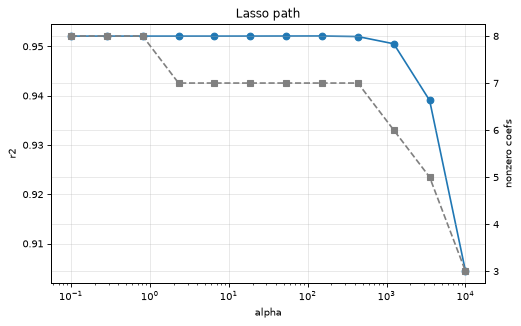

In [ ]:
num_features = ['Sqft', 'Bedrooms', 'Bathrooms', 'Age']
cat_features = ['Neighborhood']
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

X = df.drop(columns=["Price"]); y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)
alphas = np.logspace(-1, 4, 12)
r2s, nnz = [], []
for a in alphas:
    m = Pipeline([("prep", preprocess), ("lasso", Lasso(alpha=a, max_iter=5000))])
    m.fit(X_train, y_train)
    r2s.append(m.score(X_test, y_test))
    nnz.append(int((np.abs(m.named_steps["lasso"].coef_) > 1e-9).sum()))
    print(f"alpha {a:>9.1f}: r2 {r2s[-1]:.4f} | nonzero coefs {nnz[-1]}")
fig, ax1 = plt.subplots()
ax1.semilogx(alphas, r2s, marker="o", label="r2")
ax1.set_xlabel("alpha"); ax1.set_ylabel("r2")
ax2 = ax1.twinx(); ax2.semilogx(alphas, nnz, marker="s", c="gray", ls="--")
ax2.set_ylabel("nonzero coefs")
ax1.set_title("Lasso path")
best = alphas[int(np.argmax(r2s))]
print(f"best alpha: {best:.1f}")


## Notes

- R² holds up until aggressive alphas start killing real features.
- Bathrooms goes first (collinear with bedrooms) — as expected.